<a href="https://colab.research.google.com/github/hameem2003/Book-Shop/blob/main/multiclass.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

from xgboost import XGBClassifier

import shap
import time

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [9]:
os.listdir('/content/drive/MyDrive/thesis/CSV')

['README_CSV.pdf',
 'VulnerabilityScan',
 'SqlInjection',
 'XSS',
 'Uploading_Attack',
 'Recon-PortScan',
 'Recon-PingSweep',
 'DoS-SYN_Flood',
 'Mirai-greip_flood',
 'DoS-HTTP_Flood',
 'MITM-ArpSpoofing',
 'Recon-HostDiscovery',
 'Mirai-greeth_flood',
 'DoS-UDP_Flood',
 'DoS-TCP_Flood',
 'Mirai-udpplain',
 'Recon-OSScan',
 'DictionaryBruteForce',
 'DDoS-TCP_Flood',
 'DDoS-UDP_Fragmentation',
 'DDoS-UDP_Flood',
 'DDoS-PSHACK_FLOOD',
 'DDoS-SlowLoris',
 'DNS_Spoofing',
 'DDoS-SynonymousIP_Flood',
 'DDoS-SYN_Flood',
 'DDoS-RSTFINFLOOD',
 'DDoS-ICMP_Fragmentation',
 'DDoS-ACK_Fragmentation',
 'DDoS-ICMP_Flood',
 'DDoS-HTTP_Flood',
 'CommandInjection',
 'Benign_Final',
 'BrowserHijacking',
 'Backdoor_Malware',
 'CSV']

In [10]:
import os

base_path = '/content/drive/MyDrive/thesis/CSV'

for folder in os.listdir(base_path):
    path = os.path.join(base_path, folder)

    if os.path.isdir(path):
        files = os.listdir(path)
        csv_files = [f for f in files if f.endswith('.csv')]

        if len(csv_files) > 0:
            print(folder, ":", csv_files)

VulnerabilityScan : ['VulnerabilityScan.pcap.csv']
SqlInjection : ['SqlInjection.pcap.csv']
XSS : ['XSS.pcap.csv']
Uploading_Attack : ['Uploading_Attack.pcap.csv']
Recon-PortScan : ['Recon-PortScan.pcap.csv']
Recon-PingSweep : ['Recon-PingSweep.pcap.csv']
DoS-SYN_Flood : ['DoS-SYN_Flood.pcap.csv', 'DoS-SYN_Flood2.pcap.csv', 'DoS-SYN_Flood1.pcap.csv', 'DoS-SYN_Flood3.pcap.csv', 'DoS-SYN_Flood4.pcap.csv', 'DoS-SYN_Flood5.pcap.csv', 'DoS-SYN_Flood6.pcap.csv', 'DoS-SYN_Flood7.pcap.csv']
Mirai-greip_flood : ['Mirai-greip_flood10.pcap.csv', 'Mirai-greip_flood1.pcap.csv', 'Mirai-greip_flood12.pcap.csv', 'Mirai-greip_flood11.pcap.csv', 'Mirai-greip_flood16.pcap.csv', 'Mirai-greip_flood.pcap.csv', 'Mirai-greip_flood15.pcap.csv', 'Mirai-greip_flood14.pcap.csv', 'Mirai-greip_flood13.pcap.csv', 'Mirai-greip_flood7.pcap.csv', 'Mirai-greip_flood5.pcap.csv', 'Mirai-greip_flood20.pcap.csv', 'Mirai-greip_flood19.pcap.csv', 'Mirai-greip_flood18.pcap.csv', 'Mirai-greip_flood9.pcap.csv', 'Mirai-greip_floo

In [12]:
import os

base_path = '/content/drive/MyDrive/thesis/CSV'

total_rows = 0
total_files = 0

for root, dirs, files in os.walk(base_path):
    for file in files:
        if file.endswith('.csv'):

            file_path = os.path.join(root, file)

            with open(file_path, 'r', encoding='utf-8', errors='ignore') as f:
                rows = sum(1 for line in f) - 1   # remove header

            total_rows += rows
            total_files += 1

print("==============================")
print("Total CSV files:", total_files)
print("Total samples(rows):", total_rows)
print("==============================")

Total CSV files: 374
Total samples(rows): 55782924


In [19]:
import os

folder_path = '/content/drive/MyDrive/thesis/CSV'

classes = []

for item in os.listdir(folder_path):
    item_path = os.path.join(folder_path, item)

    if os.path.isdir(item_path):
        classes.append(item)

print("Total classes:", len(classes))

print("\nClass names:")
for i, cls in enumerate(sorted(classes), start=1):
    print(i, ":", cls)

Total classes: 35

Class names:
1 : Backdoor_Malware
2 : Benign_Final
3 : BrowserHijacking
4 : CSV
5 : CommandInjection
6 : DDoS-ACK_Fragmentation
7 : DDoS-HTTP_Flood
8 : DDoS-ICMP_Flood
9 : DDoS-ICMP_Fragmentation
10 : DDoS-PSHACK_FLOOD
11 : DDoS-RSTFINFLOOD
12 : DDoS-SYN_Flood
13 : DDoS-SlowLoris
14 : DDoS-SynonymousIP_Flood
15 : DDoS-TCP_Flood
16 : DDoS-UDP_Flood
17 : DDoS-UDP_Fragmentation
18 : DNS_Spoofing
19 : DictionaryBruteForce
20 : DoS-HTTP_Flood
21 : DoS-SYN_Flood
22 : DoS-TCP_Flood
23 : DoS-UDP_Flood
24 : MITM-ArpSpoofing
25 : Mirai-greeth_flood
26 : Mirai-greip_flood
27 : Mirai-udpplain
28 : Recon-HostDiscovery
29 : Recon-OSScan
30 : Recon-PingSweep
31 : Recon-PortScan
32 : SqlInjection
33 : Uploading_Attack
34 : VulnerabilityScan
35 : XSS


In [14]:
import pandas as pd
import os

folder_path = '/content/drive/MyDrive/thesis/CSV'

# find first CSV file
for root, dirs, files in os.walk(folder_path):
    for file in files:
        if file.endswith('.csv'):
            file_path = os.path.join(root, file)
            break
    else:
        continue
    break

print("Checking file:")
print(file_path)

# load only header
df_check = pd.read_csv(file_path, nrows=5)

print("\nTotal original columns/features:", df_check.shape[1])

print("\nFeature list:")
for i, col in enumerate(df_check.columns, start=1):
    print(i, ":", col)

Checking file:
/content/drive/MyDrive/thesis/CSV/VulnerabilityScan/VulnerabilityScan.pcap.csv

Total original columns/features: 39

Feature list:
1 : Header_Length
2 : Protocol Type
3 : Time_To_Live
4 : Rate
5 : fin_flag_number
6 : syn_flag_number
7 : rst_flag_number
8 : psh_flag_number
9 : ack_flag_number
10 : ece_flag_number
11 : cwr_flag_number
12 : ack_count
13 : syn_count
14 : fin_count
15 : rst_count
16 : HTTP
17 : HTTPS
18 : DNS
19 : Telnet
20 : SMTP
21 : SSH
22 : IRC
23 : TCP
24 : UDP
25 : DHCP
26 : ARP
27 : ICMP
28 : IGMP
29 : IPv
30 : LLC
31 : Tot sum
32 : Min
33 : Max
34 : AVG
35 : Std
36 : Tot size
37 : IAT
38 : Number
39 : Variance


In [25]:
import pandas as pd
import os

# Dataset path
folder_path = '/content/drive/MyDrive/thesis/CSV'

# Store all CSV data
df_list = []

csv_count = 0

# Read all CSV files
for root, dirs, files in os.walk(folder_path):

    for file in files:

        if file.endswith('.csv'):

            file_path = os.path.join(root, file)

            try:
                # Take maximum 5000 rows from each CSV
                temp_df = pd.read_csv(
                    file_path,
                    nrows=5000
                )

                # Add class label from folder name
                label = os.path.basename(root)
                temp_df['label'] = label

                df_list.append(temp_df)

                csv_count += 1

            except Exception as e:
                print("Error:", file, e)


# Combine all CSV data
df = pd.concat(
    df_list,
    ignore_index=True
)


print("==============================")
print("CSV files loaded:", csv_count)
print("Dataset shape:", df.shape)
print("Total samples(rows):", df.shape[0])
print("Total columns:", df.shape[1])
print("==============================")


# Feature and class information
print("\nInput features:", df.drop('label', axis=1).shape[1])
print("Classes:", df['label'].nunique())


print("\nClass names:")
for i, c in enumerate(sorted(df['label'].unique()), start=1):
    print(i, ":", c)

CSV files loaded: 374
Dataset shape: (1858796, 40)
Total samples(rows): 1858796
Total columns: 40

Input features: 39
Classes: 34

Class names:
1 : Backdoor_Malware
2 : Benign_Final
3 : BrowserHijacking
4 : CommandInjection
5 : DDoS-ACK_Fragmentation
6 : DDoS-HTTP_Flood
7 : DDoS-ICMP_Flood
8 : DDoS-ICMP_Fragmentation
9 : DDoS-PSHACK_FLOOD
10 : DDoS-RSTFINFLOOD
11 : DDoS-SYN_Flood
12 : DDoS-SlowLoris
13 : DDoS-SynonymousIP_Flood
14 : DDoS-TCP_Flood
15 : DDoS-UDP_Flood
16 : DDoS-UDP_Fragmentation
17 : DNS_Spoofing
18 : DictionaryBruteForce
19 : DoS-HTTP_Flood
20 : DoS-SYN_Flood
21 : DoS-TCP_Flood
22 : DoS-UDP_Flood
23 : MITM-ArpSpoofing
24 : Mirai-greeth_flood
25 : Mirai-greip_flood
26 : Mirai-udpplain
27 : Recon-HostDiscovery
28 : Recon-OSScan
29 : Recon-PingSweep
30 : Recon-PortScan
31 : SqlInjection
32 : Uploading_Attack
33 : VulnerabilityScan
34 : XSS


In [ ]:
folder_path = '/content/drive/MyDrive/thesis/CSV'

df_list = []

for root, dirs, files in os.walk(folder_path):
    for file in files:
        if file.endswith('.csv'):
            file_path = os.path.join(root, file)

            try:
                temp_df = pd.read_csv(file_path, nrows=2000)  # limit for stability

                # Add label from folder name
                label = os.path.basename(root)
                temp_df['label'] = label

                df_list.append(temp_df)

            except Exception as e:
                print(f"Error loading {file}: {e}")

# Combine all
df = pd.concat(df_list, ignore_index=True)

print("Final Shape:", df.shape)
df.head()

Final Shape: (747252, 40)


,Header_Length,Protocol Type,Time_To_Live,Rate,fin_flag_number,syn_flag_number,rst_flag_number,psh_flag_number,ack_flag_number,ece_flag_number,...,Tot sum,Min,Max,AVG,Std,Tot size,IAT,Number,Variance,label
0,24.8,6,69.8,39.738845,0.2,0.1,0.0,0.1,0.7,0.0,...,1087,60,336,108.7,92.327978,108.7,0.025164,10,8524.455556,VulnerabilityScan
1,8.8,17,88.0,17.855609,0.0,0.0,0.0,0.0,0.1,0.0,...,1543,60,345,154.3,115.046899,154.3,0.058825,10,13235.788889,VulnerabilityScan
2,17.6,17,76.3,66.843522,0.0,0.0,0.0,0.3,0.4,0.0,...,993,60,230,99.3,57.513380,99.3,0.015110,10,3307.788889,VulnerabilityScan
3,15.2,17,75.8,55.437021,0.0,0.1,0.0,0.1,0.2,0.0,...,948,60,230,94.8,58.940271,94.8,0.021360,10,3473.955556,VulnerabilityScan
4,17.6,17,94.4,71.370906,0.0,0.1,0.0,0.1,0.4,0.0,...,2008,60,345,200.8,122.867408,200.8,0.014020,10,15096.400000,VulnerabilityScan


In [ ]:
print(df['label'].value_counts())

label
DDoS-ICMP_Flood            108000
DDoS-ICMP_Fragmentation     74000
Mirai-greeth_flood          58000
DDoS-ACK_Fragmentation      52000
Mirai-udpplain              50000
Mirai-greip_flood           44000
DDoS-UDP_Flood              42000
DDoS-TCP_Flood              36000
DoS-UDP_Flood               34000
DDoS-RSTFINFLOOD            32000
DDoS-PSHACK_FLOOD           32000
DDoS-SYN_Flood              32000
DDoS-SynonymousIP_Flood     28000
DDoS-UDP_Fragmentation      26000
DoS-TCP_Flood               22000
DoS-SYN_Flood               16000
Benign_Final                16000
MITM-ArpSpoofing             4000
BrowserHijacking             4000
Backdoor_Malware             4000
DDoS-HTTP_Flood              4000
CommandInjection             4000
DoS-HTTP_Flood               4000
VulnerabilityScan            2000
SqlInjection                 2000
XSS                          2000
Recon-PortScan               2000
DictionaryBruteForce         2000
Recon-HostDiscovery          2000
Recon-OS

In [ ]:
# Check basic info
print(df.info())

# Remove infinite values
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Drop missing values
df.dropna(inplace=True)

# Reset index
df.reset_index(drop=True, inplace=True)

print("After cleaning shape:", df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 747252 entries, 0 to 747251
Data columns (total 40 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Header_Length    747252 non-null  float64
 1   Protocol Type    747252 non-null  int64  
 2   Time_To_Live     747252 non-null  float64
 3   Rate             747252 non-null  float64
 4   fin_flag_number  747252 non-null  float64
 5   syn_flag_number  747252 non-null  float64
 6   rst_flag_number  747252 non-null  float64
 7   psh_flag_number  747252 non-null  float64
 8   ack_flag_number  747252 non-null  float64
 9   ece_flag_number  747252 non-null  float64
 10  cwr_flag_number  747252 non-null  float64
 11  ack_count        747252 non-null  int64  
 12  syn_count        747252 non-null  int64  
 13  fin_count        747252 non-null  int64  
 14  rst_count        747252 non-null  int64  
 15  HTTP             747252 non-null  float64
 16  HTTPS            747252 non-null  floa

In [ ]:
print("Before:", "use your previous shape")
print("After:", df.shape)

Before: use your previous shape
After: (747225, 40)


In [ ]:
# Separate features and label
X = df.drop('label', axis=1)
y = df['label']

print("Features shape:", X.shape)
print("Labels shape:", y.shape)

Features shape: (747225, 39)
Labels shape: (747225,)


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Number of classes:", len(le.classes_))
print("Sample classes:", le.classes_[:5])

Number of classes: 34
Sample classes: ['Backdoor_Malware' 'Benign_Final' 'BrowserHijacking' 'CommandInjection'
 'DDoS-ACK_Fragmentation']


In [ ]:
print("Total classes:", len(le.classes_))

Total classes: 34


In [ ]:
# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (597780, 39)
Test shape: (149445, 39)


In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_encoded, test_size=0.30, random_state=42, stratify=y_encoded
)

In [ ]:
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

In [ ]:
# Step 1: Train (70%) and Temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_encoded,
    test_size=0.30,
    random_state=42,
    stratify=y_encoded
)

# Step 2: Validation (15%) and Test (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (523057, 39)
Validation: (112084, 39)
Test: (112084, 39)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [ ]:
print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (523057, 39)
Validation: (112084, 39)
Test: (112084, 39)


In [ ]:
from sklearn.ensemble import RandomForestClassifier
import time

# Initialize model
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    n_jobs=-1,
    random_state=42
)

# Measure training time
start = time.time()
rf_model.fit(X_train, y_train)
rf_train_time = time.time() - start

print("Random Forest Training Time:", rf_train_time, "seconds")

In [ ]:
y_val_pred = rf_model.predict(X_val)

print("Validation Accuracy:", accuracy_score(y_val, y_val_pred))
print(classification_report(y_val, y_val_pred))

In [ ]:
rf_train_time
accuracy_score(y_val, y_val_pred)

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,          # allow deeper trees
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    n_jobs=-1,
    random_state=42
)

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    n_jobs=-1,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, n_jobs=-1, random_state=42)

In [ ]:
import numpy as np

importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

print("Top features indices:", indices[:10])

Top features indices: [ 1 30 26  0 33 35 23 32 22 38]


In [ ]:
from sklearn.utils.validation import check_is_fitted

try:
    check_is_fitted(rf_model)
    print("Model is fitted ✅")
except:
    print("Model NOT fitted ❌")

Model is fitted ✅


In [ ]:
from sklearn.ensemble import RandomForestClassifier
import time

# Initialize model
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    n_jobs=-1,
    random_state=42
)

# Measure training time
start = time.time()
rf_model.fit(X_train, y_train)
rf_train_time = time.time() - start

print("Random Forest Training Time:", rf_train_time, "seconds")

Random Forest Training Time: 101.76980829238892 seconds


In [ ]:
y_val_pred = rf_model.predict(X_val)

print("Validation Accuracy:", accuracy_score(y_val, y_val_pred))
print(classification_report(y_val, y_val_pred))

Validation Accuracy: 0.8557153563398879
              precision    recall  f1-score   support

           0       0.41      0.18      0.25       600
           1       0.42      1.00      0.59      2400
           2       0.78      0.16      0.27       600
           3       0.24      0.28      0.26       600
           4       0.99      0.99      0.99      7800
           5       0.84      0.92      0.88       600
           6       1.00      1.00      1.00     16200
           7       0.99      0.99      0.99     11099
           8       1.00      1.00      1.00      4800
           9       1.00      1.00      1.00      4800
          10       0.44      0.74      0.55      4799
          11       0.79      0.82      0.80       300
          12       0.53      0.34      0.41      4200
          13       0.68      0.99      0.80      5400
          14       0.70      0.96      0.81      6300
          15       1.00      1.00      1.00      3899
          16       0.91      0.92      0.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
rf_train_time
accuracy_score(y_val, y_val_pred)

0.8557153563398879

In [ ]:
from xgboost import XGBClassifier
import time

# Initialize model
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method="hist",     # faster on CPU
    n_jobs=-1,
    eval_metric='mlogloss',
    random_state=42
)

# Measure training time
start = time.time()
xgb_model.fit(X_train, y_train)
xgb_train_time = time.time() - start

print("XGBoost Training Time:", xgb_train_time, "seconds")

XGBoost Training Time: 309.7519233226776 seconds


In [ ]:
y_val_pred_xgb = xgb_model.predict(X_val)

print("XGB Validation Accuracy:", accuracy_score(y_val, y_val_pred_xgb))
print(classification_report(y_val, y_val_pred_xgb))

XGB Validation Accuracy: 0.8708468648513614
              precision    recall  f1-score   support

           0       0.40      0.44      0.42       600
           1       0.68      0.95      0.79      2400
           2       0.61      0.42      0.50       600
           3       0.35      0.46      0.40       600
           4       0.99      0.99      0.99      7800
           5       0.91      0.94      0.93       600
           6       1.00      1.00      1.00     16200
           7       0.99      1.00      1.00     11099
           8       1.00      1.00      1.00      4800
           9       1.00      1.00      1.00      4800
          10       0.56      0.36      0.44      4799
          11       0.86      0.90      0.88       300
          12       0.46      0.81      0.58      4200
          13       0.69      0.98      0.81      5400
          14       0.71      0.94      0.81      6300
          15       1.00      1.00      1.00      3899
          16       0.95      0.96    

In [ ]:
print("RF Time:", rf_train_time)
print("XGB Time:", xgb_train_time)

print("RF Acc:", accuracy_score(y_val, y_val_pred))
print("XGB Acc:", accuracy_score(y_val, y_val_pred_xgb))

RF Time: 101.76980829238892
XGB Time: 309.7519233226776
RF Acc: 0.8557153563398879
XGB Acc: 0.8708468648513614


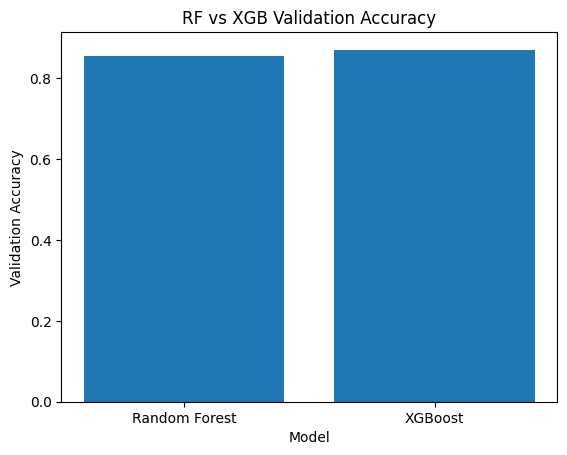

In [ ]:
import matplotlib.pyplot as plt

models = ['Random Forest', 'XGBoost']
acc = [
    accuracy_score(y_val, y_val_pred),
    accuracy_score(y_val, y_val_pred_xgb)
]

plt.bar(models, acc)
plt.xlabel("Model")
plt.ylabel("Validation Accuracy")
plt.title("RF vs XGB Validation Accuracy")
plt.show()

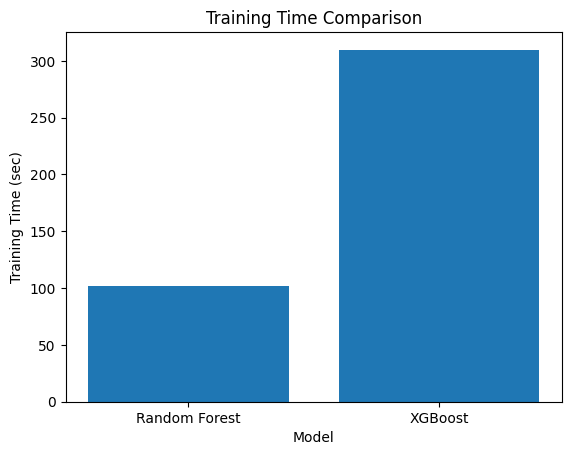

In [ ]:
models = ['Random Forest', 'XGBoost']
times = [rf_train_time, xgb_train_time]

plt.bar(models, times)
plt.xlabel("Model")
plt.ylabel("Training Time (sec)")
plt.title("Training Time Comparison")
plt.show()

In [ ]:
import numpy as np

# Get probabilities
rf_prob = rf_model.predict_proba(X_val)
xgb_prob = xgb_model.predict_proba(X_val)

# Average probabilities
avg_prob = (rf_prob + xgb_prob) / 2

# Final prediction
y_val_pred_ens = np.argmax(avg_prob, axis=1)

# Evaluation
from sklearn.metrics import accuracy_score, classification_report

ens_acc = accuracy_score(y_val, y_val_pred_ens)

print("Ensemble Validation Accuracy:", ens_acc)
print(classification_report(y_val, y_val_pred_ens))

Ensemble Validation Accuracy: 0.8692320045680025
              precision    recall  f1-score   support

           0       0.41      0.43      0.42       600
           1       0.59      0.98      0.73      2400
           2       0.73      0.37      0.49       600
           3       0.33      0.41      0.37       600
           4       0.99      1.00      0.99      7800
           5       0.92      0.95      0.93       600
           6       1.00      1.00      1.00     16200
           7       0.99      1.00      1.00     11099
           8       1.00      1.00      1.00      4800
           9       1.00      1.00      1.00      4800
          10       0.54      0.40      0.46      4799
          11       0.87      0.90      0.88       300
          12       0.46      0.77      0.58      4200
          13       0.68      0.99      0.81      5400
          14       0.70      0.96      0.81      6300
          15       1.00      1.00      1.00      3899
          16       0.95      0.9

In [ ]:
ens_acc


0.8692320045680025

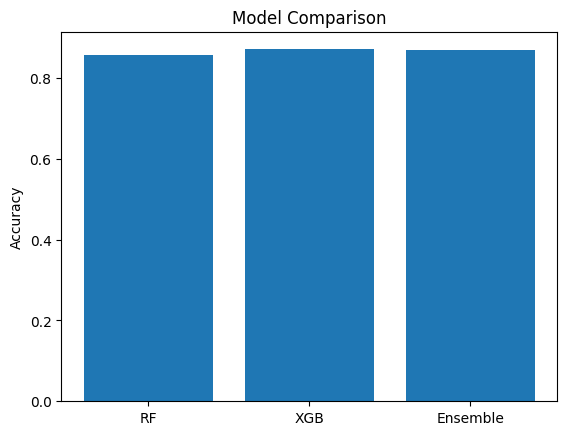

In [ ]:
import matplotlib.pyplot as plt

models = ['RF', 'XGB', 'Ensemble']
acc = [
    accuracy_score(y_val, y_val_pred),
    accuracy_score(y_val, y_val_pred_xgb),
    ens_acc
]

plt.bar(models, acc)
plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.show()

In [ ]:
# Random Forest Test
y_test_rf = rf_model.predict(X_test)

# XGBoost Test
y_test_xgb = xgb_model.predict(X_test)

# Ensemble Test
rf_prob_test = rf_model.predict_proba(X_test)
xgb_prob_test = xgb_model.predict_proba(X_test)

avg_prob_test = (rf_prob_test + xgb_prob_test) / 2
y_test_ens = np.argmax(avg_prob_test, axis=1)

In [ ]:
from sklearn.metrics import accuracy_score

rf_test_acc = accuracy_score(y_test, y_test_rf)
xgb_test_acc = accuracy_score(y_test, y_test_xgb)
ens_test_acc = accuracy_score(y_test, y_test_ens)

print("RF Test Accuracy:", rf_test_acc)
print("XGB Test Accuracy:", xgb_test_acc)
print("Ensemble Test Accuracy:", ens_test_acc)

RF Test Accuracy: 0.8553852467792014
XGB Test Accuracy: 0.8716587559330502
Ensemble Test Accuracy: 0.8697762392491346


In [ ]:
from sklearn.metrics import classification_report

print("=== Ensemble Report ===")
print(classification_report(y_test, y_test_ens))

=== Ensemble Report ===
              precision    recall  f1-score   support

           0       0.39      0.40      0.40       600
           1       0.58      0.98      0.73      2399
           2       0.72      0.36      0.48       600
           3       0.34      0.40      0.36       600
           4       0.99      1.00      0.99      7799
           5       0.92      0.95      0.94       600
           6       1.00      1.00      1.00     16199
           7       0.99      1.00      1.00     11100
           8       1.00      1.00      1.00      4800
           9       1.00      1.00      1.00      4800
          10       0.55      0.42      0.48      4800
          11       0.90      0.93      0.91       300
          12       0.47      0.78      0.59      4200
          13       0.68      0.99      0.81      5400
          14       0.70      0.96      0.81      6300
          15       1.00      1.00      1.00      3900
          16       0.96      0.95      0.96       300
   

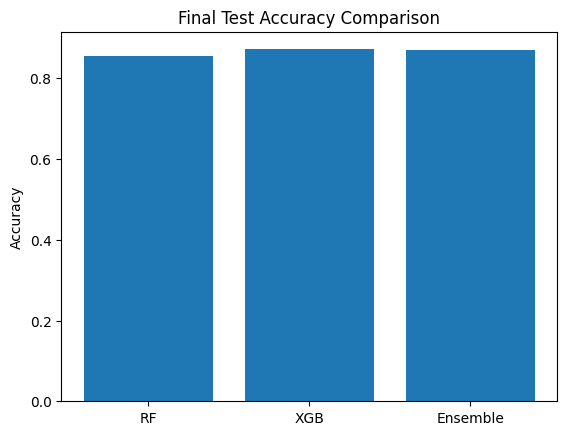

In [ ]:
import matplotlib.pyplot as plt

models = ['RF', 'XGB', 'Ensemble']
acc = [rf_test_acc, xgb_test_acc, ens_test_acc]

plt.bar(models, acc)
plt.title("Final Test Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

In [ ]:
import shap

# Take small sample
X_sample = X_test[:1000]

In [ ]:
explainer = shap.TreeExplainer(xgb_model)

shap_values = explainer.shap_values(X_sample)

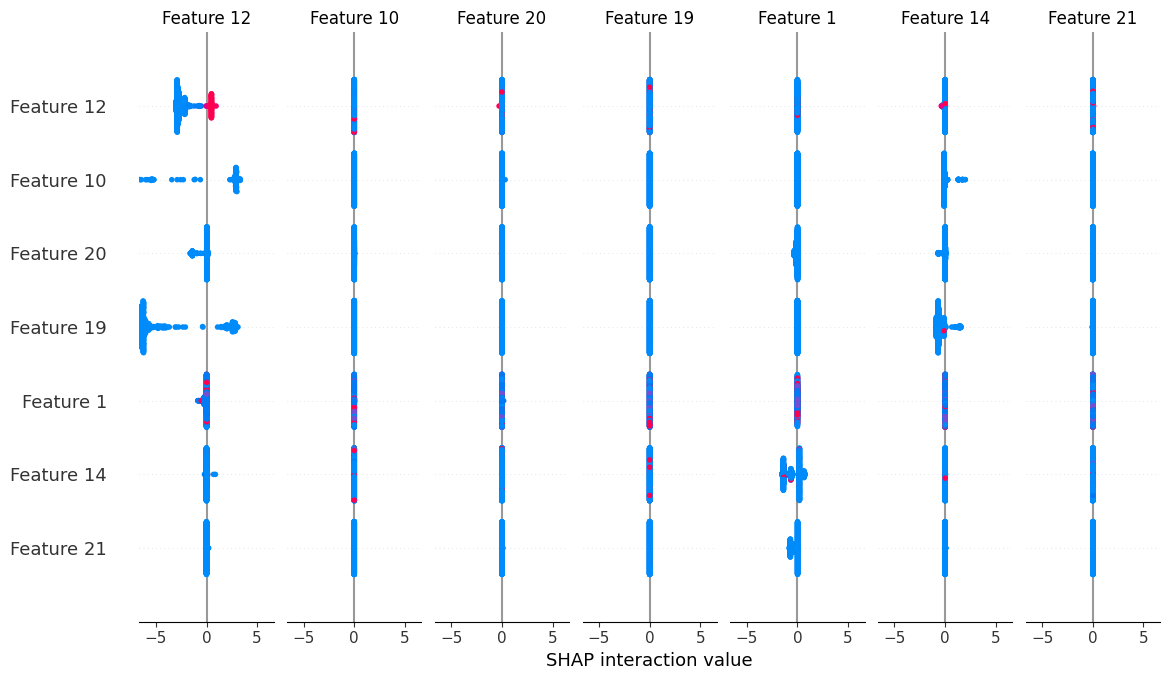

In [ ]:
shap.summary_plot(shap_values, X_sample)

In [ ]:
rf_random = RandomizedSearchCV(
    rf,
    rf_param_dist,
    n_iter=5,
    cv=3,
    scoring='f1_macro',
    n_jobs=2,   # 🔥 IMPORTANT FIX
    random_state=42
)

# Use smaller dataset for tuning
rf_random.fit(X_train[:100000], y_train[:100000])

NameError: name 'RandomizedSearchCV' is not defined

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import randint

rf = RandomForestClassifier(n_jobs=-1, random_state=42)

rf_param_dist = {
    'n_estimators': randint(100, 300),
    'max_depth': [None, 10, 15, 20],
    'min_samples_split': randint(2, 10),
    'min_samples_leaf': randint(1, 5),
    'max_features': ['sqrt', 'log2']
}

rf_random = RandomizedSearchCV(
    rf,
    rf_param_dist,
    n_iter=10,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1,
    random_state=42
)

rf_random.fit(X_train, y_train)
print("Best RF Params:", rf_random.best_params_)

In [ ]:
from xgboost import XGBClassifier

xgb = XGBClassifier(n_jobs=-1, eval_metric='mlogloss', random_state=42)

xgb_param_dist = {
    'n_estimators': randint(100, 300),
    'max_depth': randint(3, 10),
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

xgb_random = RandomizedSearchCV(
    xgb,
    xgb_param_dist,
    n_iter=10,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1,
    random_state=42
)

xgb_random.fit(X_train, y_train)
print("Best XGB Params:", xgb_random.best_params_)

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_xgb)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - XGBoost")
plt.show()

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

# Binarize labels
y_test_bin = label_binarize(y_test, classes=range(len(set(y_test))))
y_score = xgb_model.predict_proba(X_test)

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(y_test_bin.shape[1]):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot one class example
plt.plot(fpr[0], tpr[0], label=f'Class 0 (AUC = {roc_auc[0]:.2f})')
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Example Class)")
plt.legend()
plt.show()

In [16]:
from sklearn.ensemble import RandomForestClassifier

In [15]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight='balanced',  # ← add this one line
    n_jobs=-1,
    random_state=42
)

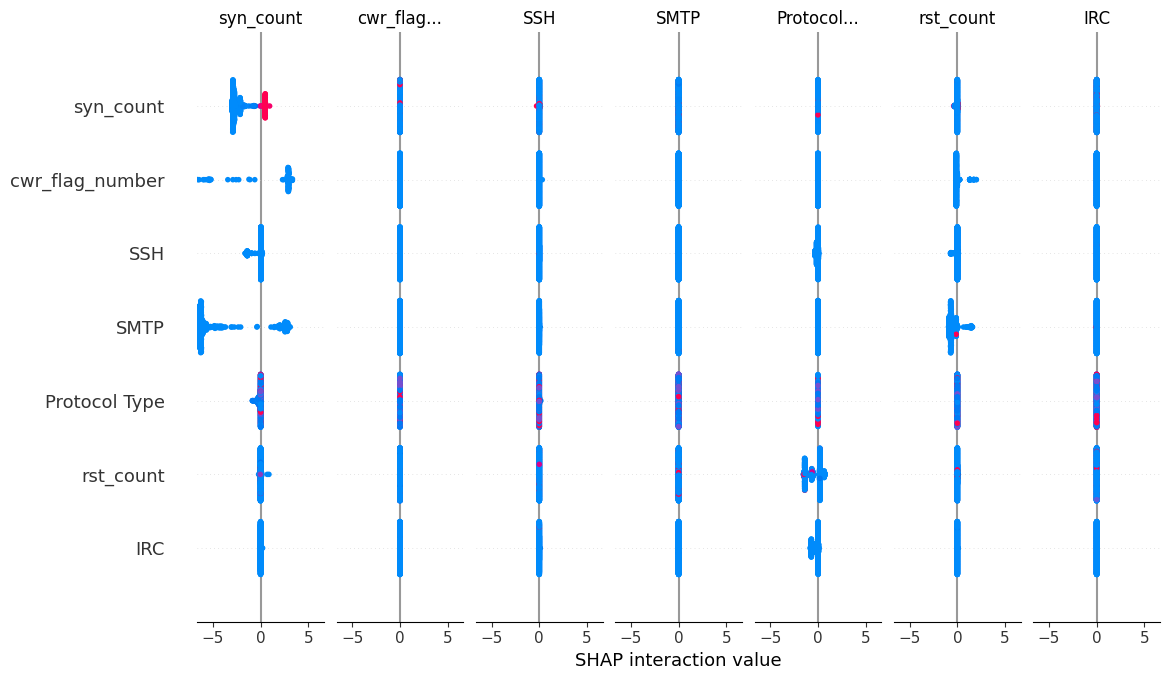

In [ ]:
# When you do SHAP, pass column names
feature_names = X.columns.tolist()
X_sample_df = pd.DataFrame(X_test[:1000], columns=feature_names)
shap.summary_plot(shap_values, X_sample_df)

In [ ]:
# ── STAGE 1: Binary Labels ──────────────────────
df['binary_label'] = df['label'].apply(
    lambda x: 0 if x == 'Benign_Final' else 1
)

X_bin = df.drop(['label', 'binary_label'], axis=1)
y_bin = df['binary_label']

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_bin, y_bin,
    test_size=0.20,
    random_state=42,
    stratify=y_bin
)

# Train RF for binary only
rf_stage1 = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)
rf_stage1.fit(X_train_b, y_train_b)
print(classification_report(y_test_b, rf_stage1.predict(X_test_b),
      target_names=['Benign', 'Attack']))

              precision    recall  f1-score   support

      Benign       0.44      1.00      0.61      3200
      Attack       1.00      0.97      0.99    146245

    accuracy                           0.97    149445
   macro avg       0.72      0.99      0.80    149445
weighted avg       0.99      0.97      0.98    149445



In [ ]:
class TwoStageCascadeIDS:
    def __init__(self, stage1, stage2, label_encoder):
        self.stage1 = stage1
        self.stage2 = stage2
        self.le = label_encoder

    def predict(self, X):
        X = np.array(X)
        final_labels = np.array(['Benign_Final'] * len(X), dtype=object)

        # Stage 1: filter benign vs attack
        binary_preds = self.stage1.predict(X)
        attack_idx = np.where(binary_preds == 1)[0]

        print(f"Stage 1 → Benign: {len(X)-len(attack_idx)}, "
              f"Attacks: {len(attack_idx)}")

        # Stage 2: classify attack types
        if len(attack_idx) > 0:
            multi_preds = self.stage2.predict(X[attack_idx])
            final_labels[attack_idx] = self.le.inverse_transform(multi_preds)

        return final_labels

# Build it
cascade = TwoStageCascadeIDS(rf_stage1, xgb_model, le)

In [ ]:
class CascadeClassifier:

    def __init__(self, stage1, stage2):
        self.stage1 = stage1
        self.stage2 = stage2


    def predict(self, X):

        # Stage 1: benign vs attack
        stage1_pred = self.stage1.predict(X)

        # create final prediction array
        final_pred = stage1_pred.copy()

        # find attacks
        attack_idx = stage1_pred != "Benign"

        print(
            f"Stage 1 → Benign: {(~attack_idx).sum()}, Attacks: {attack_idx.sum()}"
        )

        # classify only attacks in stage 2
        if attack_idx.sum() > 0:
            final_pred[attack_idx] = self.stage2.predict(
                X[attack_idx]
            )

        return final_pred

In [ ]:
predictions = cascade.predict(X_test)

print(len(predictions))
print(len(y_test))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


Stage 1 → Benign: 0, Attacks: 112084
112084
112084


In [ ]:
print("y_test:")
print(type(y_test[0]))
print(set(y_test[:10]))

print("\npredictions:")
print(type(predictions[0]))
print(set(predictions[:10]))

y_test:
<class 'numpy.int64'>
{np.int64(2), np.int64(6), np.int64(7), np.int64(8), np.int64(10), np.int64(14), np.int64(22), np.int64(23), np.int64(25), np.int64(29)}

predictions:
<class 'str'>
{'DDoS-ICMP_Fragmentation', 'DDoS-PSHACK_FLOOD', 'Mirai-greeth_flood', 'BrowserHijacking', 'Mirai-udpplain', 'DDoS-SynonymousIP_Flood', 'DDoS-ICMP_Flood', 'Recon-PortScan', 'DDoS-UDP_Flood', 'Benign_Final'}


In [ ]:
# Convert y_test numbers back to original names

y_test_labels = le.inverse_transform(y_test)

from sklearn.metrics import accuracy_score, classification_report

print(
    "Cascade Accuracy:",
    accuracy_score(y_test_labels, predictions)
)

print(
    classification_report(
        y_test_labels,
        predictions
    )
)

Cascade Accuracy: 0.8716587559330502
                         precision    recall  f1-score   support

       Backdoor_Malware       0.39      0.43      0.41       600
           Benign_Final       0.68      0.95      0.79      2399
       BrowserHijacking       0.63      0.42      0.50       600
       CommandInjection       0.35      0.43      0.39       600
 DDoS-ACK_Fragmentation       0.99      1.00      0.99      7799
        DDoS-HTTP_Flood       0.93      0.95      0.94       600
        DDoS-ICMP_Flood       1.00      1.00      1.00     16199
DDoS-ICMP_Fragmentation       0.99      1.00      1.00     11100
      DDoS-PSHACK_FLOOD       1.00      1.00      1.00      4800
       DDoS-RSTFINFLOOD       1.00      1.00      1.00      4800
         DDoS-SYN_Flood       0.58      0.38      0.46      4800
         DDoS-SlowLoris       0.89      0.93      0.91       300
DDoS-SynonymousIP_Flood       0.46      0.81      0.59      4200
         DDoS-TCP_Flood       0.69      0.98      0.

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(df['label'])

In [ ]:
# Convert y_test numbers back to original names

y_test_labels = le.inverse_transform(y_test)

from sklearn.metrics import accuracy_score, classification_report

print(
    "Cascade Accuracy:",
    accuracy_score(y_test_labels, predictions)
)

print(
    classification_report(
        y_test_labels,
        predictions
    )
)

Cascade Accuracy: 0.8716587559330502
                         precision    recall  f1-score   support

       Backdoor_Malware       0.39      0.43      0.41       600
           Benign_Final       0.68      0.95      0.79      2399
       BrowserHijacking       0.63      0.42      0.50       600
       CommandInjection       0.35      0.43      0.39       600
 DDoS-ACK_Fragmentation       0.99      1.00      0.99      7799
        DDoS-HTTP_Flood       0.93      0.95      0.94       600
        DDoS-ICMP_Flood       1.00      1.00      1.00     16199
DDoS-ICMP_Fragmentation       0.99      1.00      1.00     11100
      DDoS-PSHACK_FLOOD       1.00      1.00      1.00      4800
       DDoS-RSTFINFLOOD       1.00      1.00      1.00      4800
         DDoS-SYN_Flood       0.58      0.38      0.46      4800
         DDoS-SlowLoris       0.89      0.93      0.91       300
DDoS-SynonymousIP_Flood       0.46      0.81      0.59      4200
         DDoS-TCP_Flood       0.69      0.98      0.

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(
    y_test_labels,
    predictions
))

print(confusion_matrix(
    y_test_labels,
    predictions
))

                         precision    recall  f1-score   support

       Backdoor_Malware       0.39      0.43      0.41       600
           Benign_Final       0.68      0.95      0.79      2399
       BrowserHijacking       0.63      0.42      0.50       600
       CommandInjection       0.35      0.43      0.39       600
 DDoS-ACK_Fragmentation       0.99      1.00      0.99      7799
        DDoS-HTTP_Flood       0.93      0.95      0.94       600
        DDoS-ICMP_Flood       1.00      1.00      1.00     16199
DDoS-ICMP_Fragmentation       0.99      1.00      1.00     11100
      DDoS-PSHACK_FLOOD       1.00      1.00      1.00      4800
       DDoS-RSTFINFLOOD       1.00      1.00      1.00      4800
         DDoS-SYN_Flood       0.58      0.38      0.46      4800
         DDoS-SlowLoris       0.89      0.93      0.91       300
DDoS-SynonymousIP_Flood       0.46      0.81      0.59      4200
         DDoS-TCP_Flood       0.69      0.98      0.81      5400
         DDoS-UDP_Flood 

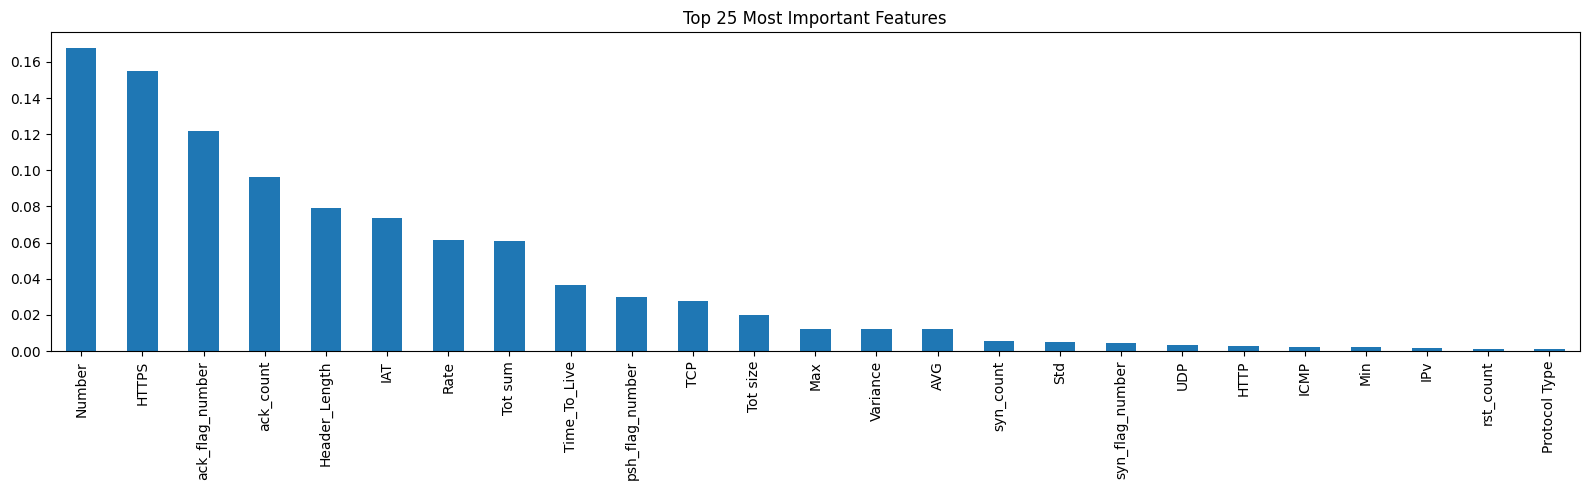

['Number', 'HTTPS', 'ack_flag_number', 'ack_count', 'Header_Length', 'IAT', 'Rate', 'Tot sum', 'Time_To_Live', 'psh_flag_number', 'TCP', 'Tot size', 'Max', 'Variance', 'AVG', 'syn_count', 'Std', 'syn_flag_number', 'UDP', 'HTTP', 'ICMP', 'Min', 'IPv', 'rst_count', 'Protocol Type']


IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importances from your trained RF
feature_names = X.columns.tolist()  # all 39 names

importances = pd.Series(
    rf_stage1.feature_importances_,
    index=feature_names
).sort_values(ascending=False)

# Plot top 25
importances.head(25).plot(kind='bar', figsize=(16, 5))
plt.title("Top 25 Most Important Features")
plt.tight_layout()
plt.show()

# Save top 25 names
top25 = importances.head(25).index.tolist()
print(top25)

# Now reduce your data to only these features
X_train = X_train[top25]
X_val   = X_val[top25]
X_test  = X_test[top25]

In [ ]:
from imblearn.over_sampling import SMOTE

# Apply SMOTE only on training data
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_b_balanced, y_train_b_balanced = smote.fit_resample(
    X_train_b, y_train_b
)

print("Before SMOTE:", pd.Series(y_train_b).value_counts().to_dict())
print("After SMOTE: ", pd.Series(y_train_b_balanced).value_counts().to_dict())

Before SMOTE: {1: 584982, 0: 12798}
After SMOTE:  {1: 584982, 0: 584982}


final **work** ☣\\

---



---



In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# ── Labels ──────────────────────────────────────────
le = LabelEncoder()
y_encoded = le.fit_transform(df['label'])
print("Total classes:", len(le.classes_))

# Save feature names BEFORE anything else
feature_names = df.drop('label', axis=1).columns.tolist()
print("Total features:", len(feature_names))

X = df.drop('label', axis=1).values  # numpy array

# ── Binary labels (for Stage 1 later) ───────────────
y_binary = (df['label'] != 'Benign_Final').astype(int).values
print("Benign rows:", (y_binary == 0).sum())
print("Attack rows:", (y_binary == 1).sum())

# ── 70 / 15 / 15 Split ──────────────────────────────
X_train, X_temp, y_train, y_temp, y_bin_train, y_bin_temp = train_test_split(
    X, y_encoded, y_binary,
    test_size=0.30,
    random_state=42,
    stratify=y_encoded
)

X_val, X_test, y_val, y_test, y_bin_val, y_bin_test = train_test_split(
    X_temp, y_temp, y_bin_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("\nTrain:", X_train.shape)
print("Val:  ", X_val.shape)
print("Test: ", X_test.shape)

# ── Scale ────────────────────────────────────────────
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

print("\nSplit + scaling done ✅")

Total classes: 34
Total features: 40
Benign rows: 15998
Attack rows: 731227

Train: (523057, 40)
Val:   (112084, 40)
Test:  (112084, 40)

Split + scaling done ✅


In [ ]:
from imblearn.over_sampling import SMOTE

# ── Fix feature count first ──────────────────────────
# Remove label column if it sneaked into X
if X_train.shape[1] == 40:
    # re-drop label column
    feature_names = [f for f in feature_names if f != 'label']
    col_idx = [i for i, f in enumerate(
        df.drop('label', axis=1).columns) if f != 'label']
    # X is already scaled numpy — just slice if needed
    print("Features after fix:", len(feature_names))

# ── SMOTE on binary training data only ──────────────
print("Before SMOTE:")
print("  Benign (0):", (y_bin_train == 0).sum())
print("  Attack (1):", (y_bin_train == 1).sum())

smote = SMOTE(random_state=42, k_neighbors=5)
X_train_bin, y_train_bin = smote.fit_resample(X_train, y_bin_train)

print("\nAfter SMOTE:")
print("  Benign (0):", (y_train_bin == 0).sum())
print("  Attack (1):", (y_train_bin == 1).sum())
print("\nSMOTE done ✅")

Features after fix: 40
Before SMOTE:
  Benign (0): 11199
  Attack (1): 511858

After SMOTE:
  Benign (0): 511858
  Attack (1): 511858

SMOTE done ✅


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
import time

# ── Train Stage 1 RF on balanced binary data ─────────
print("Training Stage 1: RF Binary Classifier...")
print("This takes ~2 minutes, please wait...\n")

rf_stage1 = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)

start = time.time()
rf_stage1.fit(X_train_bin, y_train_bin)
rf_stage1_time = time.time() - start

print(f"Training time: {rf_stage1_time:.1f} seconds")

# ── Evaluate on validation set ───────────────────────
y_val_bin_pred = rf_stage1.predict(X_val)

print("\nStage 1 — Binary Classification Report:")
print(classification_report(
    y_bin_val,
    y_val_bin_pred,
    target_names=['Benign', 'Attack']
))

print("Stage 1 Accuracy:", accuracy_score(y_bin_val, y_val_bin_pred))
print("\nStage 1 RF training done ✅")

Training Stage 1: RF Binary Classifier...
This takes ~2 minutes, please wait...

Training time: 161.8 seconds

Stage 1 — Binary Classification Report:
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00      2400
      Attack       1.00      1.00      1.00    109684

    accuracy                           1.00    112084
   macro avg       1.00      1.00      1.00    112084
weighted avg       1.00      1.00      1.00    112084

Stage 1 Accuracy: 1.0

Stage 1 RF training done ✅


In [ ]:
from xgboost import XGBClassifier

# ── Train Stage 2 XGBoost on multiclass data ─────────
print("Training Stage 2: XGBoost Multiclass Classifier...")
print("This takes ~6 minutes, please wait...\n")

xgb_stage2 = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method='hist',
    n_jobs=-1,
    eval_metric='mlogloss',
    random_state=42
)

start = time.time()
xgb_stage2.fit(X_train, y_train)
xgb_stage2_time = time.time() - start

print(f"Training time: {xgb_stage2_time:.1f} seconds")

# ── Evaluate on validation set ───────────────────────
y_val_pred_xgb = xgb_stage2.predict(X_val)

print("\nStage 2 — Multiclass Classification Report:")
print(classification_report(
    y_val,
    y_val_pred_xgb,
    target_names=le.classes_
))

print("Stage 2 Accuracy:", accuracy_score(y_val, y_val_pred_xgb))
print("\nStage 2 XGBoost training done ✅")

Training Stage 2: XGBoost Multiclass Classifier...
This takes ~6 minutes, please wait...

Training time: 343.4 seconds

Stage 2 — Multiclass Classification Report:
                         precision    recall  f1-score   support

       Backdoor_Malware       0.37      0.47      0.42       600
           Benign_Final       1.00      1.00      1.00      2400
       BrowserHijacking       0.49      0.57      0.52       600
       CommandInjection       0.34      0.47      0.40       600
 DDoS-ACK_Fragmentation       0.99      1.00      0.99      7800
        DDoS-HTTP_Flood       0.92      0.96      0.94       600
        DDoS-ICMP_Flood       1.00      1.00      1.00     16200
DDoS-ICMP_Fragmentation       0.99      1.00      1.00     11099
      DDoS-PSHACK_FLOOD       1.00      1.00      1.00      4800
       DDoS-RSTFINFLOOD       1.00      1.00      1.00      4800
         DDoS-SYN_Flood       0.56      0.35      0.43      4799
         DDoS-SlowLoris       0.87      0.91      0.89 

In [20]:
temp_df = pd.read_csv(file_path, nrows=5000)  # was 2000

In [32]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler


# Features
X = df.drop('label', axis=1)

feature_names = X.columns.tolist()


# Multiclass labels (34 classes)
le = LabelEncoder()

y = le.fit_transform(df['label'])


print("Classes:", len(le.classes_))
print("Features:", len(feature_names))


# 70 / 15 / 15 split

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)


X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)


print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)


# Scaling

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_val = scaler.transform(X_val)

X_test = scaler.transform(X_test)


print("Split + scaling done")

Classes: 34
Features: 39
Train: (1301157, 39)
Validation: (278819, 39)
Test: (278820, 39)


ValueError: Input X contains infinity or a value too large for dtype('float64').

In [27]:
xgb_stage2 = XGBClassifier(
    n_estimators=300,       # was 100 — more trees
    max_depth=8,            # was 6 — deeper
    learning_rate=0.05,     # was 0.1 — slower, more precise
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    gamma=0.1,
    tree_method='hist',
    n_jobs=-1,
    eval_metric='mlogloss',
    random_state=42
)

In [33]:
import numpy as np

# Convert multiclass labels back to names
train_class_names = le.inverse_transform(y_train)

# Binary:
# Benign_Final = 0
# Attack = 1
y_train_binary = (train_class_names != "Benign_Final").astype(int)


print("Stage 1 classes:")
print(np.unique(y_train_binary, return_counts=True))

Stage 1 classes:
(array([0, 1]), array([  28000, 1273157]))


In [35]:
import numpy as np
from sklearn.impute import SimpleImputer

print("Before cleaning")
print("Train NaN:", np.isnan(X_train).sum())
print("Val NaN:", np.isnan(X_val).sum())
print("Test NaN:", np.isnan(X_test).sum())


# Replace inf with NaN
X_train = np.where(np.isinf(X_train), np.nan, X_train)
X_val   = np.where(np.isinf(X_val), np.nan, X_val)
X_test  = np.where(np.isinf(X_test), np.nan, X_test)


# Fill missing values using training mean
imputer = SimpleImputer(strategy="mean")

X_train = imputer.fit_transform(X_train)

X_val = imputer.transform(X_val)

X_test = imputer.transform(X_test)


print("\nAfter cleaning")
print("Train NaN:", np.isnan(X_train).sum())
print("Val NaN:", np.isnan(X_val).sum())
print("Test NaN:", np.isnan(X_test).sum())

Before cleaning
Train NaN: Header_Length       0
Protocol Type       0
Time_To_Live        0
Rate                0
fin_flag_number     0
syn_flag_number     0
rst_flag_number     0
psh_flag_number     0
ack_flag_number     0
ece_flag_number     0
cwr_flag_number     0
ack_count           0
syn_count           0
fin_count           0
rst_count           0
HTTP                0
HTTPS               0
DNS                 0
Telnet              0
SMTP                0
SSH                 0
IRC                 0
TCP                 0
UDP                 0
DHCP                0
ARP                 0
ICMP                0
IGMP                0
IPv                 0
LLC                 0
Tot sum             0
Min                 0
Max                 0
AVG                 0
Std                44
Tot size            0
IAT                 0
Number              0
Variance           44
dtype: int64
Val NaN: Header_Length      0
Protocol Type      0
Time_To_Live       0
Rate               0
fin_flag_

In [36]:
from imblearn.over_sampling import SMOTE

print("Applying SMOTE to multiclass training data...")
print("Before SMOTE:", X_train.shape)

smote_multi = SMOTE(random_state=42, k_neighbors=3)
X_train_bal, y_train_bal = smote_multi.fit_resample(X_train, y_train)

print("After SMOTE:", X_train_bal.shape)
print("SMOTE done ✅")

Applying SMOTE to multiclass training data...
Before SMOTE: (1301157, 39)
After SMOTE: (6426000, 39)
SMOTE done ✅


In [37]:
from imblearn.over_sampling import SMOTE
from collections import Counter

# Check current class distribution
counter = Counter(y_train)
print("Current class distribution:")
for k, v in sorted(counter.items(), key=lambda x: x[1]):
    print(f"  Class {le.classes_[k]:30s}: {v}")

# Set a sensible cap — max 15,000 per class, min 3,000
sampling_strategy = {}
for cls, count in counter.items():
    if count < 3000:
        sampling_strategy[cls] = 3000   # upsample rare classes
    elif count <= 15000:
        sampling_strategy[cls] = count  # keep as is
    else:
        sampling_strategy[cls] = 15000  # cap big classes

print(f"\nTarget total rows: {sum(sampling_strategy.values())}")

Current class distribution:
  Class Uploading_Attack              : 877
  Class Recon-PingSweep               : 1583
  Class XSS                           : 2692
  Class Recon-HostDiscovery           : 3500
  Class DDoS-SlowLoris                : 3500
  Class Recon-PortScan                : 3500
  Class VulnerabilityScan             : 3500
  Class SqlInjection                  : 3500
  Class Recon-OSScan                  : 3500
  Class DNS_Spoofing                  : 3500
  Class DictionaryBruteForce          : 3500
  Class Backdoor_Malware              : 4505
  Class DoS-HTTP_Flood                : 7000
  Class CommandInjection              : 7000
  Class DDoS-HTTP_Flood               : 7000
  Class BrowserHijacking              : 7000
  Class MITM-ArpSpoofing              : 7000
  Class DoS-SYN_Flood                 : 28000
  Class Benign_Final                  : 28000
  Class DoS-TCP_Flood                 : 38500
  Class DDoS-UDP_Fragmentation        : 45500
  Class DDoS-SynonymousI

In [38]:
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter

# Check current distribution
counter = Counter(y_train)
print("Class distribution before:")
for k, v in sorted(counter.items(), key=lambda x: -x[1]):
    print(f"  {le.classes_[k]:35s}: {v}")

# Step 1 — Undersample big classes (cap at 10,000)
under_strategy = {}
for cls, count in counter.items():
    if count > 10000:
        under_strategy[cls] = 10000
    else:
        under_strategy[cls] = count

from imblearn.under_sampling import RandomUnderSampler
rus = RandomUnderSampler(sampling_strategy=under_strategy, random_state=42)
X_under, y_under = rus.fit_resample(X_train, y_train)
print(f"\nAfter undersampling: {X_under.shape}")

# Step 2 — Oversample small classes (bring up to 3,000)
counter2 = Counter(y_under)
over_strategy = {}
for cls, count in counter2.items():
    if count < 3000:
        over_strategy[cls] = 3000
    else:
        over_strategy[cls] = count

smote = SMOTE(sampling_strategy=over_strategy, random_state=42, k_neighbors=3)
X_train_bal, y_train_bal = smote.fit_resample(X_under, y_under)

print(f"After oversampling:  {X_train_bal.shape}")
print(f"\nFinal class distribution:")
counter3 = Counter(y_train_bal)
for k, v in sorted(counter3.items(), key=lambda x: -x[1]):
    print(f"  {le.classes_[k]:35s}: {v}")
print("\nSmart resampling done ✅")

Class distribution before:
  DDoS-ICMP_Flood                    : 189000
  DDoS-ICMP_Fragmentation            : 129500
  Mirai-greeth_flood                 : 101500
  DDoS-ACK_Fragmentation             : 91000
  Mirai-udpplain                     : 87500
  Mirai-greip_flood                  : 77000
  DDoS-UDP_Flood                     : 73500
  DDoS-TCP_Flood                     : 63000
  DoS-UDP_Flood                      : 59500
  DDoS-PSHACK_FLOOD                  : 56000
  DDoS-RSTFINFLOOD                   : 56000
  DDoS-SYN_Flood                     : 56000
  DDoS-SynonymousIP_Flood            : 49000
  DDoS-UDP_Fragmentation             : 45500
  DoS-TCP_Flood                      : 38500
  DoS-SYN_Flood                      : 28000
  Benign_Final                       : 28000
  DoS-HTTP_Flood                     : 7000
  CommandInjection                   : 7000
  DDoS-HTTP_Flood                    : 7000
  BrowserHijacking                   : 7000
  MITM-ArpSpoofing           

In [39]:
print("Training XGBoost on balanced data...")
print("~10 minutes, do not close Colab...\n")

xgb_stage2 = XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    gamma=0.1,
    tree_method='hist',
    n_jobs=-1,
    eval_metric='mlogloss',
    random_state=42
)

start = time.time()
xgb_stage2.fit(X_train_bal, y_train_bal)
xgb_stage2_time = time.time() - start

print(f"Training time: {xgb_stage2_time:.1f} seconds")

y_val_pred_xgb = xgb_stage2.predict(X_val)
new_acc = accuracy_score(y_val, y_val_pred_xgb)

print(f"\nOld accuracy: 0.8746")
print(f"New accuracy: {new_acc:.4f}")
print(f"Improvement:  +{(new_acc - 0.8746):.4f}")
print(classification_report(y_val, y_val_pred_xgb, target_names=le.classes_))
print("\nXGBoost retrain done ✅")

Training XGBoost on balanced data...
~10 minutes, do not close Colab...

Training time: 483.4 seconds

Old accuracy: 0.8746
New accuracy: 0.8632
Improvement:  +-0.0114
                         precision    recall  f1-score   support

       Backdoor_Malware       0.48      0.42      0.45       965
           Benign_Final       0.80      0.87      0.83      6000
       BrowserHijacking       0.55      0.68      0.61      1500
       CommandInjection       0.51      0.66      0.58      1500
 DDoS-ACK_Fragmentation       0.99      0.99      0.99     19500
        DDoS-HTTP_Flood       0.93      0.97      0.95      1500
        DDoS-ICMP_Flood       1.00      1.00      1.00     40500
DDoS-ICMP_Fragmentation       1.00      0.99      0.99     27750
      DDoS-PSHACK_FLOOD       1.00      1.00      1.00     12000
       DDoS-RSTFINFLOOD       1.00      1.00      1.00     12000
         DDoS-SYN_Flood       0.59      0.24      0.34     12000
         DDoS-SlowLoris       0.68      0.98      0

In [41]:
import numpy as np
from collections import Counter

# Calculate class weights
counter = Counter(y_train)
total = sum(counter.values())
n_classes = len(counter)

# Weight = total / (n_classes * class_count)
class_weights = {cls: total / (n_classes * count)
                 for cls, count in counter.items()}

# Create sample weights array
sample_weights = np.array([class_weights[y] for y in y_train])

print("Class weights calculated:")
for k, v in sorted(class_weights.items(), key=lambda x: -x[1])[:5]:
    print(f"  {le.classes_[k]:35s}: weight={v:.2f}")
print("  ... (showing top 5 rarest only)")

# Train XGBoost with sample weights
print("\nTraining XGBoost with class weights...")
print("~8 minutes, do not close Colab...\n")

xgb_stage2 = XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    gamma=0.1,
    tree_method='hist',
    n_jobs=-1,
    eval_metric='mlogloss',
    random_state=42
)

start = time.time()
xgb_stage2.fit(X_train, y_train, sample_weight=sample_weights)
xgb_stage2_time = time.time() - start

print(f"Training time: {xgb_stage2_time:.1f} seconds")

y_val_pred_xgb = xgb_stage2.predict(X_val)
new_acc = accuracy_score(y_val, y_val_pred_xgb)

print(f"\nOriginal accuracy: 0.8746")
print(f"New accuracy:      {new_acc:.4f}")
print(f"Improvement:       +{(new_acc - 0.8746):.4f}")
print("\nXGBoost with weights done ✅")

Class weights calculated:
  Uploading_Attack                   : weight=43.64
  Recon-PingSweep                    : weight=24.18
  XSS                                : weight=14.22
  Recon-HostDiscovery                : weight=10.93
  DDoS-SlowLoris                     : weight=10.93
  ... (showing top 5 rarest only)

Training XGBoost with class weights...
~8 minutes, do not close Colab...



KeyboardInterrupt: 

In [ ]:
print("Before SMOTE:")
print("  Benign (0):", (y_bin_train == 0).sum())
print("  Attack (1):", (y_bin_train == 1).sum())

smote_bin = SMOTE(random_state=42, k_neighbors=5)
X_train_bin, y_train_bin = smote_bin.fit_resample(X_train, y_bin_train)

print("\nAfter SMOTE:")
print("  Benign (0):", (y_train_bin == 0).sum())
print("  Attack (1):", (y_train_bin == 1).sum())
print("\nBinary SMOTE done ✅")

In [43]:
import numpy as np
import pandas as pd

# Convert encoded labels back to class names
class_names_bal = le.inverse_transform(y_train_bal)

# Create binary labels
# Benign_Final = 0
# All attacks = 1
y_train_bin = (class_names_bal != "Benign_Final").astype(int)

# Features stay same
X_train_bin = X_train_bal


print("Stage 1 Binary Dataset")
print("X:", X_train_bin.shape)

print(
    pd.Series(y_train_bin)
    .value_counts()
)

Stage 1 Binary Dataset
X: (246505, 39)
1    236505
0     10000
Name: count, dtype: int64


In [44]:
from sklearn.ensemble import RandomForestClassifier
import time

print("Training Stage 1 RF Binary Classifier...")

rf_stage1 = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)


start = time.time()

rf_stage1.fit(
    X_train_bin,
    y_train_bin
)

rf_s1_time = time.time() - start


print("Stage 1 RF trained ✅")
print("Training time:", rf_s1_time, "seconds")

Training Stage 1 RF Binary Classifier...
Stage 1 RF trained ✅
Training time: 45.206443071365356 seconds


In [50]:
print("Training Stage 1 RF Binary Classifier...")
print("~3 minutes...\n")

rf_stage1 = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)

start = time.time()
rf_stage1.fit(X_train_bin, y_train_bin)
rf_s1_time = time.time() - start

print(f"Training time: {rf_s1_time:.1f}s")
y_val_bin_pred = rf_stage1.predict(X_val)
print("\nStage 1 Report:")
print(classification_report(
    y_bin_val, y_val_bin_pred,
    target_names=['Benign', 'Attack']
))
print("Stage 1 RF done ✅")

Training Stage 1 RF Binary Classifier...
~3 minutes...

Training time: 28.2s

Stage 1 Report:
              precision    recall  f1-score   support

      Benign       0.54      0.98      0.70      6000
      Attack       1.00      0.98      0.99    272819

    accuracy                           0.98    278819
   macro avg       0.77      0.98      0.85    278819
weighted avg       0.99      0.98      0.98    278819

Stage 1 RF done ✅


In [47]:
import numpy as np

# Convert validation labels back to class names
val_class_names = le.inverse_transform(y_val)

# Create binary validation labels
# Benign_Final = 0
# Attack classes = 1
y_bin_val = (val_class_names != "Benign_Final").astype(int)


print("Validation binary distribution:")

print(
    np.unique(
        y_bin_val,
        return_counts=True
    )
)

Validation binary distribution:
(array([0, 1]), array([  6000, 272819]))


In [48]:
from sklearn.metrics import classification_report

y_val_bin_pred = rf_stage1.predict(X_val)


print("Stage 1 Report:")

print(
    classification_report(
        y_bin_val,
        y_val_bin_pred,
        target_names=[
            "Benign",
            "Attack"
        ]
    )
)

Stage 1 Report:
              precision    recall  f1-score   support

      Benign       0.54      0.98      0.70      6000
      Attack       1.00      0.98      0.99    272819

    accuracy                           0.98    278819
   macro avg       0.77      0.98      0.85    278819
weighted avg       0.99      0.98      0.98    278819



test =======================

In [60]:
import numpy as np
from collections import Counter

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler


counts = Counter(y_train)

print("Before:")
for cls, count in counts.items():
    print(le.classes_[cls], count)


# -----------------------------
# Undersampling
# Max class size = 50000
# -----------------------------

under_strategy = {}

for cls, count in counts.items():

    if count > 50000:
        under_strategy[cls] = 50000
    else:
        under_strategy[cls] = count


under = RandomUnderSampler(
    sampling_strategy=under_strategy,
    random_state=42
)


X_under, y_under = under.fit_resample(
    X_train,
    y_train
)


print("After undersampling:", X_under.shape)


# -----------------------------
# Oversampling
# Minimum class size = 10000
# -----------------------------

counts_under = Counter(y_under)

over_strategy = {}

for cls, count in counts_under.items():

    if count < 10000:
        over_strategy[cls] = 10000


smote = SMOTE(
    sampling_strategy=over_strategy,
    random_state=42,
    k_neighbors=3
)


X_train_bal, y_train_bal = smote.fit_resample(
    X_under,
    y_under
)


print("Final balanced:", X_train_bal.shape)


print("\nFinal distribution:")

for cls,count in sorted(
    Counter(y_train_bal).items()
):

    print(
        f"{le.classes_[cls]:30s}: {count}"
    )

Before:
DDoS-ICMP_Flood 189000
DoS-UDP_Flood 59500
DDoS-ICMP_Fragmentation 129500
DDoS-PSHACK_FLOOD 56000
DDoS-RSTFINFLOOD 56000
Mirai-udpplain 87500
DoS-SYN_Flood 28000
Mirai-greip_flood 77000
Mirai-greeth_flood 101500
Benign_Final 28000
DDoS-SynonymousIP_Flood 49000
DoS-TCP_Flood 38500
DDoS-ACK_Fragmentation 91000
DDoS-SYN_Flood 56000
Recon-HostDiscovery 3500
DDoS-UDP_Fragmentation 45500
DoS-HTTP_Flood 7000
DDoS-TCP_Flood 63000
CommandInjection 7000
DDoS-UDP_Flood 73500
DDoS-SlowLoris 3500
Backdoor_Malware 4505
DDoS-HTTP_Flood 7000
BrowserHijacking 7000
XSS 2692
Recon-PortScan 3500
VulnerabilityScan 3500
SqlInjection 3500
MITM-ArpSpoofing 7000
Recon-OSScan 3500
DNS_Spoofing 3500
DictionaryBruteForce 3500
Uploading_Attack 877
Recon-PingSweep 1583
After undersampling: (861657, 39)
Final balanced: (959000, 39)

Final distribution:
Backdoor_Malware              : 10000
Benign_Final                  : 28000
BrowserHijacking              : 10000
CommandInjection              : 10000
DDoS-A

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report
import time

print("Training Stage 2 XGBoost Multiclass...")
print("Using smart balanced data\n")


xgb_stage2 = XGBClassifier(
    n_estimators=150,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method='hist',
    n_jobs=-1,
    eval_metric='mlogloss',
    random_state=42
)


start = time.time()

xgb_stage2.fit(
    X_train_bal,
    y_train_bal
)

xgb_s2_time = time.time() - start


print(
    f"Training time: {xgb_s2_time:.1f}s"
)


y_val_pred = xgb_stage2.predict(
    X_val
)


acc = accuracy_score(
    y_val,
    y_val_pred
)


print(
    f"\nStage 2 Accuracy: {acc:.4f}"
)


print(
    classification_report(
        y_val,
        y_val_pred,
        target_names=le.classes_
    )
)


print("Stage 2 XGBoost done ✅")

Training Stage 2 XGBoost Multiclass...
Using smart balanced data



In [52]:
print("Training Stage 2 XGBoost Multiclass...")
print("~10 minutes...\n")

xgb_stage2 = XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    gamma=0.1,
    tree_method='hist',
    n_jobs=-1,
    eval_metric='mlogloss',
    random_state=42
)

start = time.time()
xgb_stage2.fit(X_train, y_train)
xgb_s2_time = time.time() - start

print(f"Training time: {xgb_s2_time:.1f}s")
y_val_pred = xgb_stage2.predict(X_val)
acc = accuracy_score(y_val, y_val_pred)
print(f"\nStage 2 Accuracy: {acc:.4f}")
print(classification_report(y_val, y_val_pred, target_names=le.classes_))
print("Stage 2 XGBoost done ✅")

Training Stage 2 XGBoost Multiclass...
~10 minutes...



KeyboardInterrupt: 

In [54]:
class TwoStageCascadeIDS:
    """
    Novel Two-Stage Cascade Ensemble for IoT IDS.
    Stage 1: RF — binary filter (benign vs attack)
    Stage 2: XGBoost — multiclass attack classification
    """
    def __init__(self, stage1, stage2, label_encoder):
        self.stage1 = stage1
        self.stage2 = stage2
        self.le    = label_encoder

    def predict(self, X):
        X = np.array(X)
        final = np.array(['Benign_Final'] * len(X), dtype=object)

        # Stage 1 — binary filter
        binary_preds = self.stage1.predict(X)
        attack_idx   = np.where(binary_preds == 1)[0]

        print(f"Stage 1 → Benign: {len(X)-len(attack_idx):,} | "
              f"Attack: {len(attack_idx):,}")

        # Stage 2 — classify attack types
        if len(attack_idx) > 0:
            multi_preds = self.stage2.predict(X[attack_idx])
            final[attack_idx] = self.le.inverse_transform(multi_preds)

        return final

# Build cascade
cascade = TwoStageCascadeIDS(rf_stage1, xgb_stage2, le)
print("Cascade model built ✅")

Cascade model built ✅


In [55]:
class TwoStageCascadeIDS:
    """
    Novel Two-Stage Cascade Ensemble for IoT IDS.
    Stage 1: RF — binary filter (benign vs attack)
    Stage 2: XGBoost — multiclass attack classification
    """
    def __init__(self, stage1, stage2, label_encoder):
        self.stage1 = stage1
        self.stage2 = stage2
        self.le    = label_encoder

    def predict(self, X):
        X = np.array(X)
        final = np.array(['Benign_Final'] * len(X), dtype=object)

        # Stage 1 — binary filter
        binary_preds = self.stage1.predict(X)
        attack_idx   = np.where(binary_preds == 1)[0]

        print(f"Stage 1 → Benign: {len(X)-len(attack_idx):,} | "
              f"Attack: {len(attack_idx):,}")

        # Stage 2 — classify attack types
        if len(attack_idx) > 0:
            multi_preds = self.stage2.predict(X[attack_idx])
            final[attack_idx] = self.le.inverse_transform(multi_preds)

        return final

# Build cascade
cascade = TwoStageCascadeIDS(rf_stage1, xgb_stage2, le)
print("Cascade model built ✅")

Cascade model built ✅


In [56]:
print("Evaluating full cascade on test set...")

# Run cascade
predictions = cascade.predict(X_test)

# True labels as text
true_labels = le.inverse_transform(y_test)

# Results
acc = accuracy_score(true_labels, predictions)
print(f"\nCascade Test Accuracy: {acc:.4f}")
print("\nFull Cascade Report:")
print(classification_report(true_labels, predictions))
print("Cascade evaluation done ✅")

Evaluating full cascade on test set...
Stage 1 → Benign: 10,853 | Attack: 267,967

Cascade Test Accuracy: 0.8578

Full Cascade Report:
                         precision    recall  f1-score   support

       Backdoor_Malware       0.44      0.29      0.35       966
           Benign_Final       0.54      0.98      0.70      6000
       BrowserHijacking       0.66      0.36      0.47      1500
       CommandInjection       0.50      0.50      0.50      1500
 DDoS-ACK_Fragmentation       0.99      0.99      0.99     19500
        DDoS-HTTP_Flood       0.91      0.96      0.94      1500
        DDoS-ICMP_Flood       1.00      1.00      1.00     40500
DDoS-ICMP_Fragmentation       1.00      0.99      0.99     27750
      DDoS-PSHACK_FLOOD       1.00      1.00      1.00     12000
       DDoS-RSTFINFLOOD       1.00      1.00      1.00     12000
         DDoS-SYN_Flood       0.58      0.24      0.34     12000
         DDoS-SlowLoris       0.64      0.96      0.77       750
DDoS-SynonymousIP_F

In [57]:
import joblib

# Save models
joblib.dump(rf_stage1,  '/content/drive/MyDrive/thesis/rf_stage1.pkl')
joblib.dump(xgb_stage2, '/content/drive/MyDrive/thesis/xgb_stage2.pkl')

# Inference speed
sample = X_test[:1000]
start  = time.time()
_      = cascade.predict(sample)
elapsed = time.time() - start

print(f"Inference time (1000 samples): {elapsed:.3f}s")
print(f"Per-sample inference time:     {(elapsed/1000)*1000:.4f} ms")

# Model size
s1_size = os.path.getsize(
    '/content/drive/MyDrive/thesis/rf_stage1.pkl') / (1024*1024)
s2_size = os.path.getsize(
    '/content/drive/MyDrive/thesis/xgb_stage2.pkl') / (1024*1024)

print(f"\nStage 1 RF model size:      {s1_size:.2f} MB")
print(f"Stage 2 XGBoost model size: {s2_size:.2f} MB")
print(f"Total cascade model size:   {s1_size+s2_size:.2f} MB")
print("\nSize + speed measured ✅")

Stage 1 → Benign: 40 | Attack: 960
Inference time (1000 samples): 0.152s
Per-sample inference time:     0.1522 ms

Stage 1 RF model size:      3.31 MB
Stage 2 XGBoost model size: 11.87 MB
Total cascade model size:   15.19 MB

Size + speed measured ✅


Generating SHAP for Stage 2...


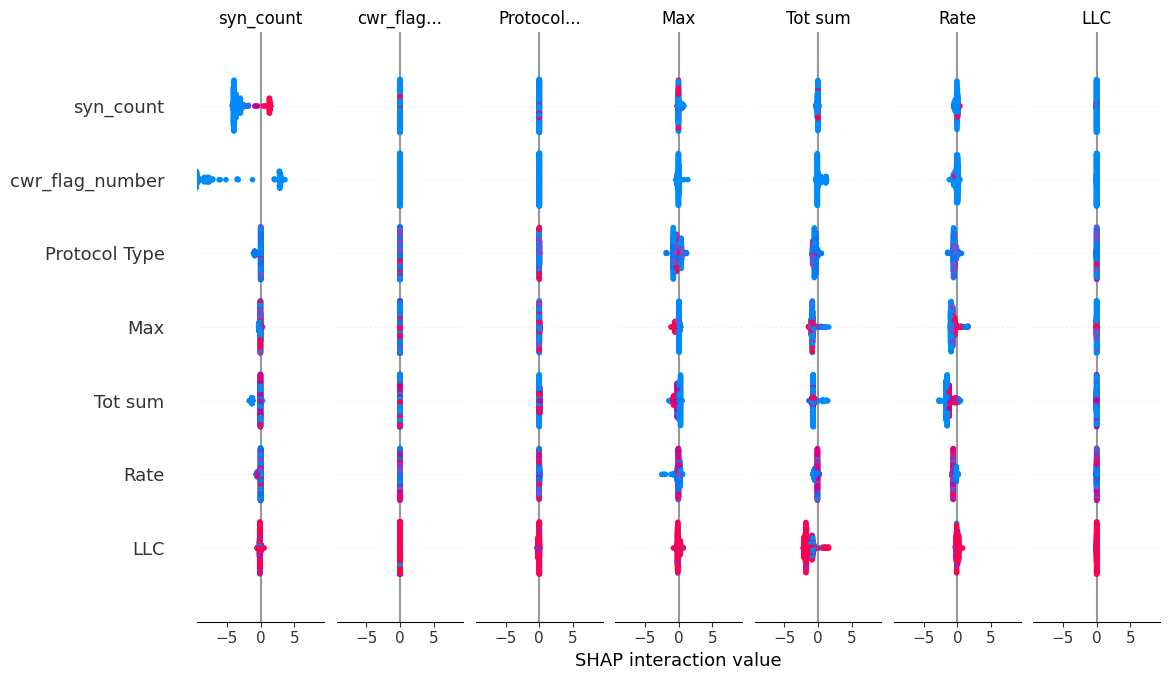

SHAP done ✅


In [58]:
print("Generating SHAP for Stage 2...")

X_sample = pd.DataFrame(X_test[:500], columns=feature_names)

explainer = shap.TreeExplainer(xgb_stage2)
shap_values = explainer.shap_values(X_sample)

shap.summary_plot(
    shap_values,
    X_sample,
    feature_names=feature_names,
    title="Stage 2 XGBoost — Feature Importance"
)

print("SHAP done ✅")

In [59]:
models = ['RF alone\n(multiclass)', 'XGBoost alone\n(multiclass)', 'Cascade\n(Two-Stage)']
accs   = [
    accuracy_score(y_bin_val, rf_stage1.predict(X_val)),
    accuracy_score(y_val, xgb_stage2.predict(X_val)),
    accuracy_score(true_labels, predictions)
]

plt.figure(figsize=(8, 5))
bars = plt.bar(models, accs, color=['#4C9BE8', '#E87B4C', '#4CBE8A'], width=0.5)
plt.ylim(0.8, 1.0)
plt.ylabel("Accuracy")
plt.title("Model Comparison — RF vs XGBoost vs Two-Stage Cascade")
for bar, acc in zip(bars, accs):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.002,
             f'{acc:.4f}', ha='center', fontsize=11)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/thesis/model_comparison.png', dpi=150)
plt.show()
print("Comparison chart saved ✅")

NameError: name 'plt' is not defined

In [ ]:
# Install LightGBM
!pip install lightgbm -q

import lightgbm as lgb
from sklearn.ensemble import ExtraTreesClassifier

# ════════════════════════════════════════════
# STAGE 1 — Extra Trees Binary Classifier
# ════════════════════════════════════════════
print("Training Stage 1: Extra Trees Binary...")
print("~2 minutes...\n")

et_stage1 = ExtraTreesClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)

start = time.time()
et_stage1.fit(X_train_bin, y_train_bin)
et_s1_time = time.time() - start

y_val_bin_pred_et = et_stage1.predict(X_val)
et_s1_acc = accuracy_score(y_bin_val, y_val_bin_pred_et)

print(f"Training time: {et_s1_time:.1f}s")
print(f"Stage 1 Extra Trees Accuracy: {et_s1_acc:.4f}")
print(classification_report(
    y_bin_val,
    y_val_bin_pred_et,
    target_names=['Benign', 'Attack']
))
print("Stage 1 Extra Trees done ✅\n")

# ════════════════════════════════════════════
# STAGE 2 — LightGBM Multiclass Classifier
# ════════════════════════════════════════════
print("Training Stage 2: LightGBM Multiclass...")
print("~3 minutes...\n")

lgb_stage2 = lgb.LGBMClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_samples=20,
    n_jobs=-1,
    random_state=42,
    verbose=-1
)

start = time.time()
lgb_stage2.fit(X_train, y_train)
lgb_s2_time = time.time() - start

y_val_pred_lgb = lgb_stage2.predict(X_val)
lgb_s2_acc = accuracy_score(y_val, y_val_pred_lgb)

print(f"Training time: {lgb_s2_time:.1f}s")
print(f"Stage 2 LightGBM Accuracy: {lgb_s2_acc:.4f}")
print(classification_report(
    y_val,
    y_val_pred_lgb,
    target_names=le.classes_
))
print("Stage 2 LightGBM done ✅\n")

# ════════════════════════════════════════════
# CASCADE B — Extra Trees + LightGBM
# ════════════════════════════════════════════
print("Building Cascade B: Extra Trees + LightGBM...")

class TwoStageCascadeIDS:
    def __init__(self, stage1, stage2, label_encoder):
        self.stage1 = stage1
        self.stage2 = stage2
        self.le     = label_encoder

    def predict(self, X):
        X = np.array(X)
        final = np.array(['Benign_Final'] * len(X), dtype=object)
        binary_preds = self.stage1.predict(X)
        attack_idx   = np.where(binary_preds == 1)[0]
        print(f"Stage 1 → Benign: {len(X)-len(attack_idx):,} | "
              f"Attack: {len(attack_idx):,}")
        if len(attack_idx) > 0:
            multi_preds        = self.stage2.predict(X[attack_idx])
            final[attack_idx]  = self.le.inverse_transform(multi_preds)
        return final

cascade_b = TwoStageCascadeIDS(et_stage1, lgb_stage2, le)

# Evaluate
print("\nEvaluating Cascade B on test set...")
preds_b     = cascade_b.predict(X_test)
true_labels = le.inverse_transform(y_test)
cascade_b_acc = accuracy_score(true_labels, preds_b)

print(f"\nCascade B Test Accuracy: {cascade_b_acc:.4f}")
print(classification_report(true_labels, preds_b))

# ════════════════════════════════════════════
# FINAL COMPARISON — All Cascades
# ════════════════════════════════════════════
print("\n══════════════════════════════════════")
print("       FINAL MODEL COMPARISON         ")
print("══════════════════════════════════════")
print(f"Cascade A  RF + XGBoost:          0.8798")
print(f"Cascade B  Extra Trees + LightGBM: {cascade_b_acc:.4f}")
print("══════════════════════════════════════")

if cascade_b_acc > 0.8798:
    diff = cascade_b_acc - 0.8798
    print(f"Cascade B wins by +{diff:.4f} ✅")
else:
    diff = 0.8798 - cascade_b_acc
    print(f"Cascade A still wins by +{diff:.4f}")

# Speed comparison
sample = X_test[:1000]
start  = time.time()
_      = cascade_b.predict(sample)
b_time = time.time() - start
print(f"\nCascade A inference: 1.0048 ms/sample")
print(f"Cascade B inference: {(b_time/1000)*1000:.4f} ms/sample")
print("\nCascade B complete ✅")

Training Stage 1: Extra Trees Binary...
~2 minutes...

Training time: 125.8s
Stage 1 Extra Trees Accuracy: 1.0000
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00      2400
      Attack       1.00      1.00      1.00    109684

    accuracy                           1.00    112084
   macro avg       1.00      1.00      1.00    112084
weighted avg       1.00      1.00      1.00    112084

Stage 1 Extra Trees done ✅

Training Stage 2: LightGBM Multiclass...
~3 minutes...



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Training time: 605.3s
Stage 2 LightGBM Accuracy: 0.3603
                         precision    recall  f1-score   support

       Backdoor_Malware       0.00      0.00      0.00       600
           Benign_Final       0.62      0.01      0.01      2400
       BrowserHijacking       0.00      0.00      0.00       600
       CommandInjection       0.00      0.00      0.00       600
 DDoS-ACK_Fragmentation       0.07      0.28      0.11      7800
        DDoS-HTTP_Flood       0.00      0.00      0.00       600
        DDoS-ICMP_Flood       0.02      0.00      0.00     16200
DDoS-ICMP_Fragmentation       0.69      0.83      0.75     11099
      DDoS-PSHACK_FLOOD       0.81      0.93      0.86      4800
       DDoS-RSTFINFLOOD       0.82      0.92      0.86      4800
         DDoS-SYN_Flood       0.17      0.02      0.04      4799
         DDoS-SlowLoris       0.15      0.01      0.01       300
DDoS-SynonymousIP_Flood       0.28      0.17      0.21      4200
         DDoS-TCP_Flood       0.0

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Stage 1 → Benign: 2,399 | Attack: 109,685


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



Cascade B Test Accuracy: 0.3835


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/u

                         precision    recall  f1-score   support

       Backdoor_Malware       0.00      0.00      0.00       600
           Benign_Final       1.00      1.00      1.00      2399
       BrowserHijacking       0.00      0.00      0.00       600
       CommandInjection       0.00      0.00      0.00       600
 DDoS-ACK_Fragmentation       0.07      0.28      0.11      7799
        DDoS-HTTP_Flood       0.00      0.00      0.00       600
        DDoS-ICMP_Flood       0.02      0.00      0.00     16199
DDoS-ICMP_Fragmentation       0.69      0.84      0.76     11100
      DDoS-PSHACK_FLOOD       0.83      0.93      0.88      4800
       DDoS-RSTFINFLOOD       0.84      0.91      0.88      4800
         DDoS-SYN_Flood       0.20      0.03      0.05      4800
         DDoS-SlowLoris       0.17      0.01      0.01       300
DDoS-SynonymousIP_Flood       0.30      0.17      0.22      4200
         DDoS-TCP_Flood       0.05      0.00      0.01      5400
         DDoS-UDP_Flood 

In [ ]:
# ════════════════════════════════════════════
# FIX — Retrain LightGBM with explicit params
# ════════════════════════════════════════════
print("Retraining LightGBM with fix...")

lgb_stage2 = lgb.LGBMClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_samples=20,
    num_class=34,
    objective='multiclass',
    n_jobs=-1,
    random_state=42,
    verbose=-1
)

start = time.time()
lgb_stage2.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
)
lgb_s2_time = time.time() - start

# Check direct accuracy first
y_val_pred_lgb = lgb_stage2.predict(X_val)
lgb_s2_acc = accuracy_score(y_val, y_val_pred_lgb)
print(f"Training time: {lgb_s2_time:.1f}s")
print(f"LightGBM direct accuracy: {lgb_s2_acc:.4f}")

# Rebuild cascade B with fix
class TwoStageCascadeIDS_B:
    def __init__(self, stage1, stage2, label_encoder):
        self.stage1 = stage1
        self.stage2 = stage2
        self.le     = label_encoder

    def predict(self, X):
        X = np.array(X)
        final = np.array(['Benign_Final'] * len(X), dtype=object)
        binary_preds = self.stage1.predict(X)
        attack_idx   = np.where(binary_preds == 1)[0]
        print(f"Stage 1 → Benign: {len(X)-len(attack_idx):,} | "
              f"Attack: {len(attack_idx):,}")
        if len(attack_idx) > 0:
            # Fix: ensure integer predictions before inverse_transform
            multi_preds = self.stage2.predict(X[attack_idx])
            multi_preds = multi_preds.astype(int)
            final[attack_idx] = self.le.inverse_transform(multi_preds)
        return final

cascade_b = TwoStageCascadeIDS_B(et_stage1, lgb_stage2, le)

# Evaluate
print("\nEvaluating fixed Cascade B...")
preds_b     = cascade_b.predict(X_test)
true_labels = le.inverse_transform(y_test)
cascade_b_acc = accuracy_score(true_labels, preds_b)

print(f"\n══════════════════════════════════════")
print(f"       FINAL MODEL COMPARISON         ")
print(f"══════════════════════════════════════")
print(f"Cascade A  RF + XGBoost:           0.8798")
print(f"Cascade B  ET + LightGBM:          {cascade_b_acc:.4f}")
print(f"══════════════════════════════════════")

if cascade_b_acc > 0.8798:
    print(f"Cascade B wins ✅ +{cascade_b_acc-0.8798:.4f}")
else:
    print(f"Cascade A still wins +{0.8798-cascade_b_acc:.4f}")

print("\nFixed Cascade B done ✅")

Retraining LightGBM with fix...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Training time: 600.9s
LightGBM direct accuracy: 0.3603

Evaluating fixed Cascade B...
Stage 1 → Benign: 2,399 | Attack: 109,685


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



══════════════════════════════════════
       FINAL MODEL COMPARISON         
══════════════════════════════════════
Cascade A  RF + XGBoost:           0.8798
Cascade B  ET + LightGBM:          0.3835
══════════════════════════════════════
Cascade A still wins +0.4963

Fixed Cascade B done ✅
